# 05 — Modelling (Bonus)
Predict next-day trader profitability. Cluster traders into behavioral archetypes.

**Input:** `data/processed/daily_metrics.csv`, `data/processed/trader_summary.csv`
**Output:** `outputs/model_results.csv`, `outputs/trader_archetypes.csv`

In [1]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from src.config import DATA_PROCESSED, OUTPUTS_DIR, PALETTE
from src.utils import setup_plotting, save_chart, print_section
setup_plotting()
pd.set_option('display.max_columns', None)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## 1. Load data

In [2]:
daily   = pd.read_csv(f'{DATA_PROCESSED}/daily_metrics.csv')
traders = pd.read_csv(f'{DATA_PROCESSED}/trader_summary.csv')
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['Account','date'])
print(f'Daily: {daily.shape}   Traders: {traders.shape}')

Daily: (77, 18)   Traders: (32, 14)


## 2. Build classification features

In [3]:
daily['sentiment_enc'] = (daily['Classification'] == 'Greed').astype(int)
daily['target'] = daily.groupby('Account')['is_profitable'].shift(-1)
daily = daily.dropna(subset=['target'])
daily['target'] = daily['target'].astype(int)

feature_cols = [
    'sentiment_enc',
    'daily_pnl',
    'num_trades',
    'win_rate',
    'avg_size_usd',
    'buy_sell_ratio',
    'total_fee',
]
model_df = daily[feature_cols + ['target']].dropna()
X = model_df[feature_cols]
y = model_df['target']

print(f'Feature matrix : {X.shape}')
print(f'Target balance :\n{y.value_counts(normalize=True).round(3)}')

Feature matrix : (45, 7)
Target balance :
target
1    0.889
0    0.111
Name: proportion, dtype: float64


## 3. Train / test split and scale

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

Train: (36, 7)   Test: (9, 7)


## 4. Model comparison

In [5]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:,1]
    cv    = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc').mean()
    results.append({
        'Model'      : name,
        'Test Acc'   : round((preds == y_test).mean(), 4),
        'ROC-AUC'    : round(roc_auc_score(y_test, proba), 4),
        'CV ROC-AUC' : round(cv, 4),
    })

results_df = pd.DataFrame(results)
print_section('MODEL COMPARISON')
print(results_df.to_string(index=False))
results_df.to_csv(f'{OUTPUTS_DIR}/model_results.csv', index=False)


  MODEL COMPARISON
              Model  Test Acc  ROC-AUC  CV ROC-AUC
Logistic Regression    0.8889   0.6250         NaN
      Random Forest    0.8889   0.6250         NaN
  Gradient Boosting    0.8889   0.5625         NaN


## 5. Feature importance

Chart saved: /app/charts/12_feature_importance.png


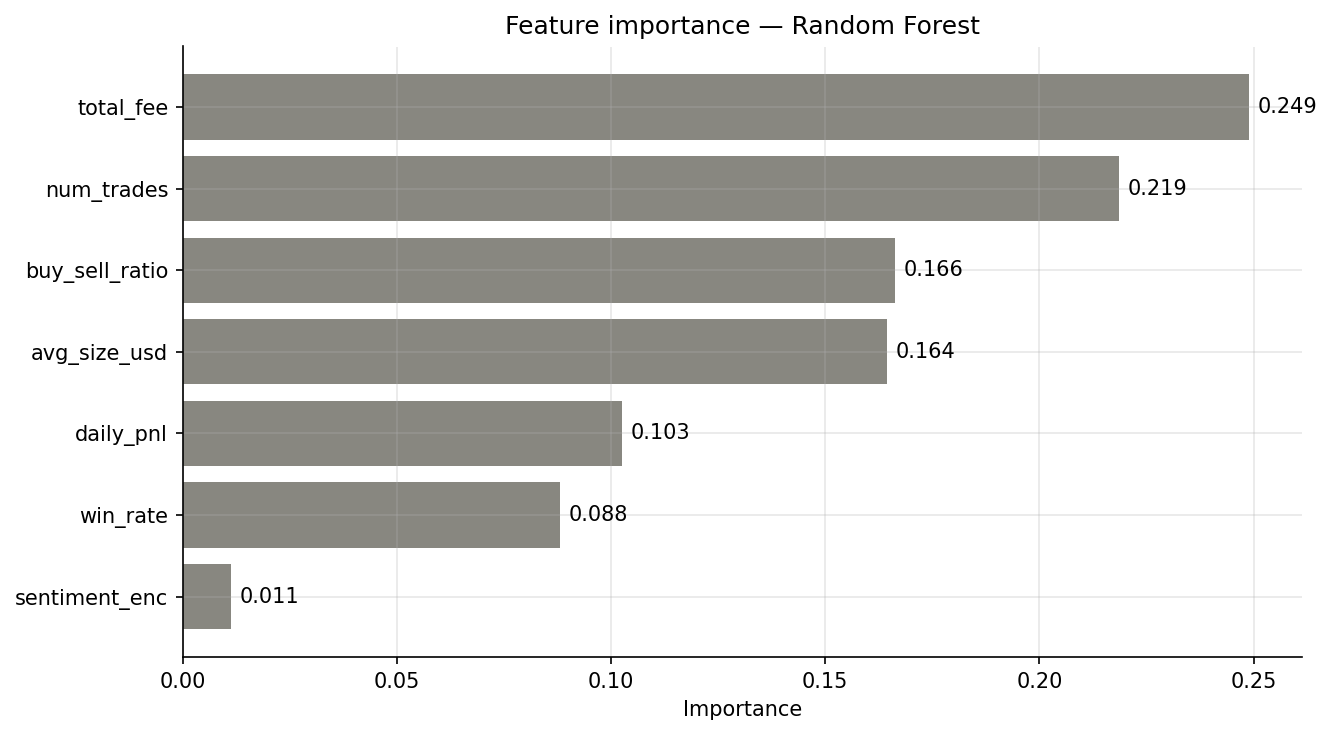

In [6]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index, importances.values,
               color=PALETTE['neutral'], edgecolor='none')
ax.set_title('Feature importance — Random Forest')
ax.set_xlabel('Importance')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
save_chart(fig, '12_feature_importance.png')
plt.show()

## 6. KMeans clustering — trader archetypes

Chart saved: /app/charts/13_elbow_plot.png


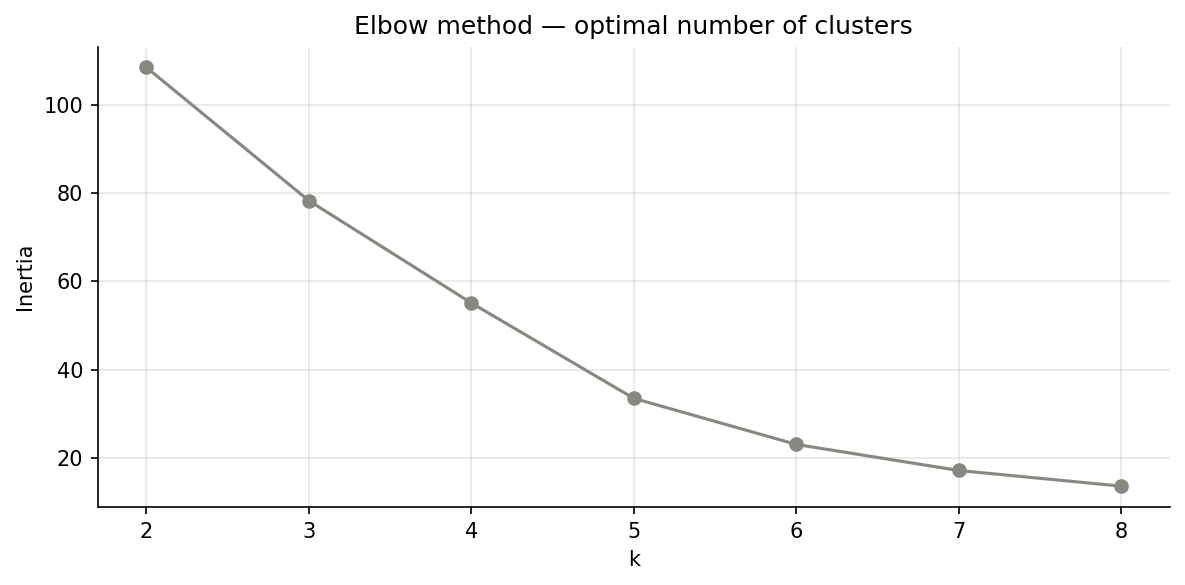

In [7]:
cluster_cols = ['avg_size_usd','avg_trades_day','overall_winrate','avg_buy_sell','total_fees_paid']
cluster_data = traders[cluster_cols].dropna()
scaler_c     = StandardScaler()
cluster_sc   = scaler_c.fit_transform(cluster_data)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 9), inertias, marker='o', color=PALETTE['neutral'])
ax.set_title('Elbow method — optimal number of clusters')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
plt.tight_layout()
save_chart(fig, '13_elbow_plot.png')
plt.show()

In [8]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
traders_c = traders.loc[cluster_data.index].copy()
traders_c['cluster'] = km_final.fit_predict(cluster_sc)

profile = traders_c.groupby('cluster')[cluster_cols + ['total_pnl']].mean().round(3)
print_section('CLUSTER PROFILES')
print(profile.to_string())

cluster_names = {
    profile['avg_size_usd'].idxmax()    : 'High-Volume Trader',
    profile['avg_size_usd'].idxmin()    : 'Low-Volume Trader',
    profile['overall_winrate'].idxmax() : 'Consistent Winner',
    profile['avg_trades_day'].idxmax()  : 'Active Trader',
}
traders_c['archetype'] = traders_c['cluster'].map(cluster_names)
print()
print(traders_c['archetype'].value_counts())


  CLUSTER PROFILES
         avg_size_usd  avg_trades_day  overall_winrate  avg_buy_sell  total_fees_paid   total_pnl
cluster                                                                                          
0           18317.726        3353.875            0.389  1.068000e+00        34360.564  161888.196
1            4574.899        1693.694            0.378  1.123457e+09         2496.203  286912.273
2           15783.012        3000.000            0.208  1.115000e+11        28169.111  403501.648
3            2667.418       19728.500            0.472  8.970000e-01        10310.513  875670.096

archetype
High-Volume Trader    2
Active Trader         2
Name: count, dtype: int64


Chart saved: /app/charts/14_cluster_pca.png


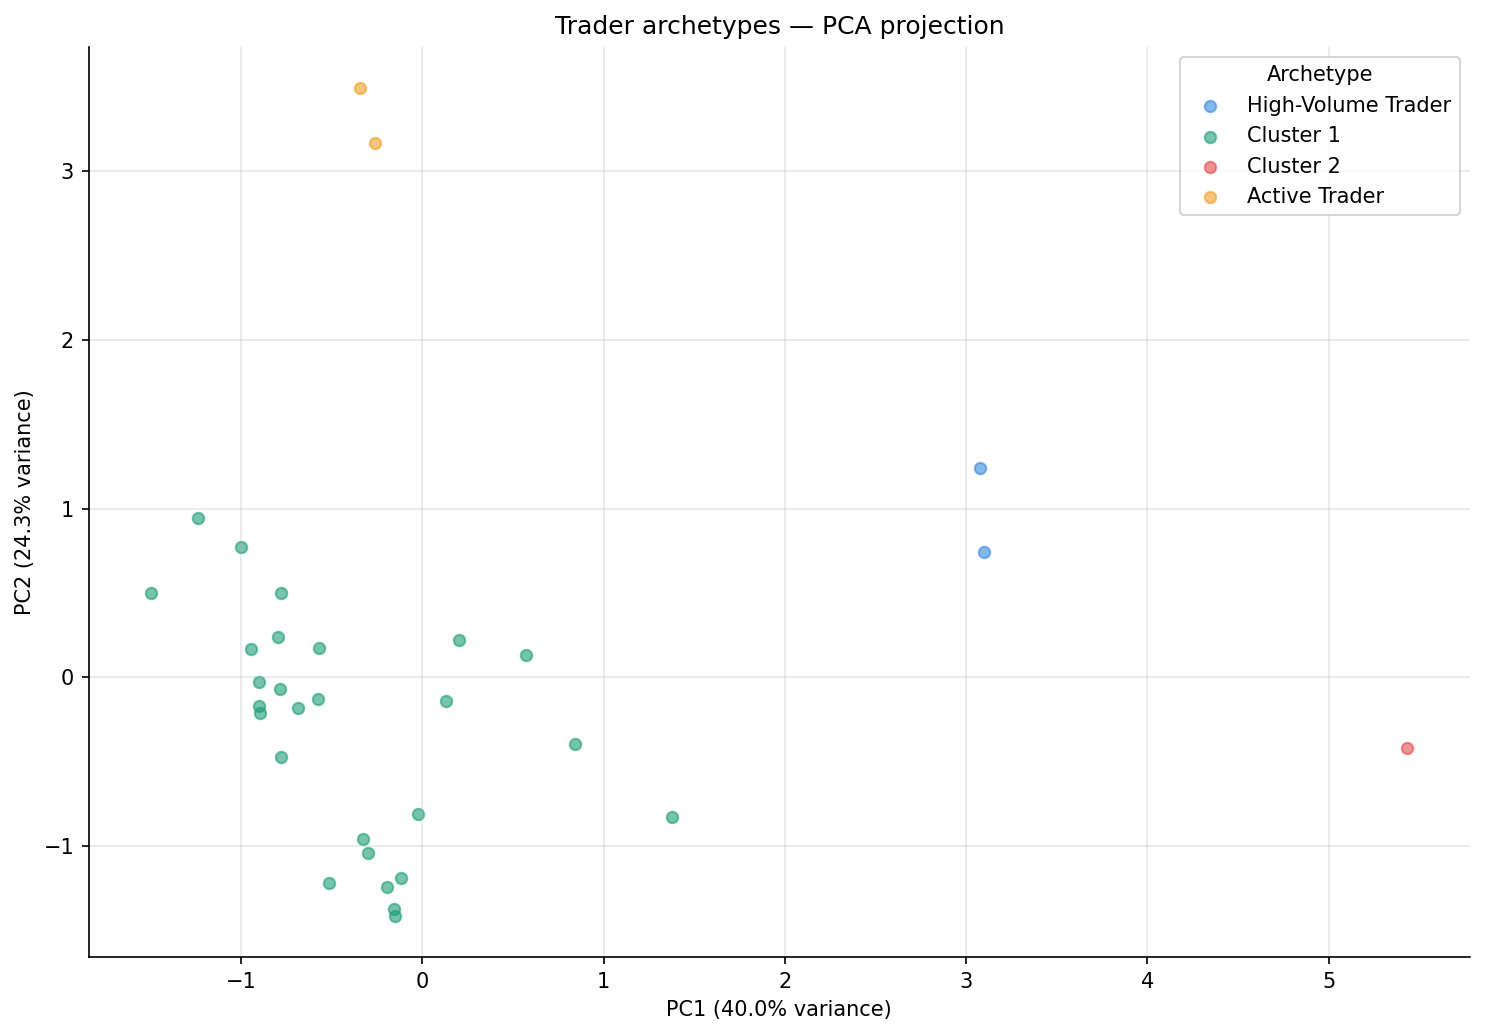

Saved: outputs/trader_archetypes.csv


In [9]:
pca    = PCA(n_components=2)
coords = pca.fit_transform(cluster_sc)
pca_df = pd.DataFrame(coords, columns=['PC1','PC2'])
pca_df['cluster']   = traders_c['cluster'].values
pca_df['archetype'] = traders_c['archetype'].values

colors_c = ['#378ADD','#1D9E75','#E24B4A','#EF9F27']
fig, ax = plt.subplots(figsize=(10, 7))
for i, (cl, grp) in enumerate(pca_df.groupby('cluster')):
    label = cluster_names.get(cl, f'Cluster {cl}')
    ax.scatter(grp['PC1'], grp['PC2'],
               color=colors_c[i % len(colors_c)],
               label=label, alpha=0.6, s=30)
ax.set_title('Trader archetypes — PCA projection')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Archetype')
plt.tight_layout()
save_chart(fig, '14_cluster_pca.png')
plt.show()

traders_c.to_csv(f'{OUTPUTS_DIR}/trader_archetypes.csv', index=False)
print(f'Saved: outputs/trader_archetypes.csv')